# Kaggle — Baseline ML Models (Improved)
**TF-IDF + Logistic Regression | TF-IDF + SVM | XGBoost | LightGBM**

Labels: `CLEAN (0)` · `OFFENSIVE (1)` · `HATE (2)`

## 1. Cài đặt thư viện

In [4]:
!pip install datasets underthesea xgboost lightgbm optuna -q

## 2. Cấu hình & Import

In [5]:
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score,
)
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from xgboost import XGBClassifier
import lightgbm as lgb
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
tqdm.pandas()

# --- Cấu hình chung ---
LABEL_NAMES = ['CLEAN', 'OFFENSIVE', 'HATE']
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports ready.')

All imports ready.


## 3. Load Dataset

In [6]:
train_df = pd.read_csv("/kaggle/input/datasets/mnhtndev/kaggle-hsd/train_df.csv")
dev_df   = pd.read_csv("/kaggle/input/datasets/mnhtndev/kaggle-hsd/val_df.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/mnhtndev/kaggle-hsd/test_df.csv")

print(f"Train: {len(train_df):,} | Dev: {len(dev_df):,} | Test: {len(test_df):,}")
print(f"Columns: {train_df.columns.tolist()}")
print()

label_map = {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}
print("Label distribution (train):")
print(train_df['labels'].value_counts().sort_index().rename(label_map))
train_df.head(3)

Train: 5,166 | Dev: 738 | Test: 1,476
Columns: ['cmt_col', 'labels']

Label distribution (train):
labels
CLEAN        2097
OFFENSIVE    1746
HATE         1323
Name: count, dtype: int64


,cmt_col,labels
0,cặc,1.0
1,đr hết thời cày rank bk còn ngợp,0.0
2,Diễn viên hô ni hút mà ngại gì mấy khác kk,0.0


## 4. Tiền xử lý văn bản

In [7]:
from underthesea import word_tokenize

# ===== Teencode dictionary =====
TEENCODE_MAP = {
    # Phủ định / Trạng thái
    'ko': 'không', 'kh': 'không', 'khong': 'không', 'kg': 'không',
    'hok': 'không', 'hk': 'không', 'hem': 'không', 'kô': 'không',
    'chx': 'chưa', 'chua': 'chưa',
    'r': 'rồi', 'rui': 'rồi', 'ròi': 'rồi', 'oy': 'rồi', 'uj': 'rồi',

    # Đại từ nhân xưng
    'mk': 'mình', 'mik': 'mình', 'mh': 'mình',
    'tui': 'tôi', 'tau': 'tao',
    'may': 'mày', 'mi': 'mày',
    'bn': 'bạn', 'ban': 'bạn',
    'no': 'nó', 'bon no': 'bọn nó', 'bọn no': 'bọn nó',
    'mng': 'mọi người', 'mn': 'mọi người', 'ae': 'anh em',

    # Động từ / Trạng từ
    'dc': 'được', 'đc': 'được', 'dk': 'được', 'đk': 'được',
    'đươc': 'được', 'duoc': 'được',
    'vs': 'với', 'voi': 'với',
    'j': 'gì', 'zì': 'gì', 'zi': 'gì',
    'ntn': 'như thế nào', 'nso': 'như sao',
    'biet': 'biết', 'bit': 'biết', 'hieu': 'hiểu', 'nghi': 'nghĩ',
    'muon': 'muốn', 'hoac': 'hoặc', 'neu': 'nếu', 'nen': 'nên',
    'giet': 'giết', 'chui': 'chửi', 'danh': 'đánh',

    # Liên từ / Trạng từ nối
    'nx': 'nhưng', 'nhg': 'nhưng', 'nhưg': 'nhưng', 'nma': 'nhưng mà',
    'cx': 'cũng', 'cg': 'cũng', 'cung': 'cũng', 'cũg': 'cũng',
    'ms': 'mới', 'boi': 'bởi',

    # Cảm thán
    'oke': 'ok', 'okie': 'ok', 'okê': 'ok', 'okey': 'ok',
    'uh': 'ừ', 'uk': 'ừ', 'uhm': 'ừ', 'ừm': 'ừ',
    'yep': 'đúng', 'yup': 'đúng',
    'haha': 'haha', 'hehe': 'hehe', 'hihi': 'hehe', 'huhu': 'buồn',
    'haiz': 'thở dài', 'haizz': 'thở dài', 'haizzz': 'thở dài',
    'wtf': 'cái gì vậy', 'omg': 'ôi trời',
    'lol': 'buồn cười', 'lmao': 'buồn cười',
    'fck': 'chửi thề', 'fk': 'chửi thề', 'gg': 'xong rồi', 'ez': 'dễ',

    # Trạng thái / Mô tả
    'bt': 'bình thường', 'bth': 'bình thường',
    'noob': 'tệ', 'nub': 'tệ', 'gà': 'tệ',
    'xàm': 'vô nghĩa', 'nhảm': 'vô nghĩa',
    'pro': 'giỏi',

    # Hate speech — biến thể chính tả cố ý
    'vl': 'vãi lồn', 'vcl': 'vãi cái lồn', 'vkl': 'vãi kép lồn',
    'vll': 'vãi lồn', 'vleu': 'vãi lồn', 'vloz': 'vãi lồn',
    'dm': 'đụ má', 'đm': 'đụ má', 'd.m': 'đụ má', 'đ.m': 'đụ má',
    'đmm': 'đụ má mày', 'dmm': 'đụ má mày',
    'đmcs': 'đụ má chúng mày', 'dmcs': 'đụ má chúng mày',
    'đtm': 'địt mẹ', 'dtm': 'địt mẹ',
    'cl': 'cái lồn', 'lon': 'lồn', 'loz': 'lồn', 'l0n': 'lồn',
    'clgt': 'cái lồn gì thế',
    'đéo': 'không', 'deo': 'không', 'éo': 'không',
    'cc': 'cái con', 'thg': 'thằng',
    'ngu': 'ngu', 'đần': 'đần độn', 'khùng': 'điên', 'dien': 'điên',
    'cút': 'cút', 'cut': 'cút',
    'câm': 'câm miệng', 'im mồm': 'câm miệng',

    # Mạng xã hội
    'fb': 'facebook', 'yt': 'youtube', 'tt': 'tiktok', 'zl': 'zalo',
    'ig': 'instagram', 'cmt': 'bình luận', 'rep': 'trả lời',

    # Địa danh
    'vn': 'việt nam', 'hn': 'hà nội', 'hcm': 'hồ chí minh', 'sg': 'sài gòn',

    # Khác
    'iu': 'yêu', 'ieu': 'yêu',
}


def normalize_text(text: str) -> str:
    """Chuẩn hóa văn bản tiếng Việt: lowercase, xóa noise, teencode."""
    if not isinstance(text, str):
        return ''

    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)       # URL
    text = re.sub(r'\b0[0-9]{9,10}\b', ' ', text)        # SĐT
    text = re.sub(r'\S+@\S+', ' ', text)                  # Email
    text = re.sub(r'<[^>]+>', ' ', text)                   # HTML
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)           # Ký tự lặp (aaa→aa)
    text = re.sub(r'[^\w\s]', ' ', text)                   # Ký tự đặc biệt
    text = re.sub(r'\s+', ' ', text).strip()               # Khoảng trắng thừa

    words = text.split()
    words = [TEENCODE_MAP.get(w, w) for w in words]
    return ' '.join(words)


def preprocess(text: str, use_word_segment: bool = True) -> str:
    """Pipeline: normalize → word segmentation (underthesea)."""
    text = normalize_text(text)
    if use_word_segment and text:
        try:
            text = word_tokenize(text, format='text')
        except Exception:
            pass
    return text


# Sanity check
sample = 'mày ko hiểu gì hết, ngu vcl!!'
print(f'Original : {sample}')
print(f'Processed: {preprocess(sample)}')

Original : mày ko hiểu gì hết, ngu vcl!!
Processed: mày không hiểu gì hết ngu_vãi cái lồn


## 5. Áp dụng tiền xử lý

In [8]:
print('Preprocessing texts (word segmentation)...')
print('⏳ ~5-10 phút do tách từ underthesea')

for df, name in [(train_df, 'Train'), (dev_df, 'Dev'), (test_df, 'Test')]:
    df['text_processed'] = df['cmt_col'].progress_apply(preprocess)
    print(f'  {name}: done')

print('\nSample:')
for _, row in train_df.sample(3, random_state=42).iterrows():
    lbl = label_map[row['labels']]
    print(f'  [{lbl:>9}] {row["cmt_col"][:55]} → {row["text_processed"][:55]}')

Preprocessing texts (word segmentation)...
⏳ ~5-10 phút do tách từ underthesea


  0%|          | 0/5166 [00:00<?, ?it/s]

  Train: done


  0%|          | 0/738 [00:00<?, ?it/s]

  Dev: done


  0%|          | 0/1476 [00:00<?, ?it/s]

  Test: done

Sample:
  [OFFENSIVE] nhìn cx xinh nhà cx có vẻ điều kiện mà mất nhận thức vậ → nhìn cũng xinh nhà cũng có_vẻ điều_kiện mà mất nhận_thứ
  [OFFENSIVE] Tưởng bố thế nào, chỉ mõm → tưởng bố thế_nào chỉ mõm
  [OFFENSIVE] Nguyên Dảk chửi 1 lần cũng là chửi, 10 lần cũng là chửi → nguyên dảk chửi 1 lần cũng là chửi 10 lần cũng là chửi 


## 6. TF-IDF Vectorization

In [9]:
X_train_text = train_df['text_processed'].fillna('').tolist()
X_dev_text   = dev_df['text_processed'].fillna('').tolist()
X_test_text  = test_df['text_processed'].fillna('').tolist()

y_train = train_df['labels'].values
y_dev   = dev_df['labels'].values
y_test  = test_df['labels'].values

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b',
)

X_train = tfidf.fit_transform(X_train_text)
X_dev   = tfidf.transform(X_dev_text)
X_test  = tfidf.transform(X_test_text)

print(f'Vocab size: {len(tfidf.vocabulary_):,}')
print(f'X_train: {X_train.shape}  |  X_dev: {X_dev.shape}  |  X_test: {X_test.shape}')

Vocab size: 11,519
X_train: (5166, 11519)  |  X_dev: (738, 11519)  |  X_test: (1476, 11519)


## 7. Evaluation Helpers

In [10]:
results_table = []


def evaluate_model(name, model, X_eval, y_eval, split_name='Dev'):
    """Evaluate & return metrics dict. Appends to results_table."""
    y_pred = model.predict(X_eval)

    acc         = accuracy_score(y_eval, y_pred)
    f1_macro    = f1_score(y_eval, y_pred, average='macro')
    f1_weighted = f1_score(y_eval, y_pred, average='weighted')
    f1_cls      = f1_score(y_eval, y_pred, average=None)

    print(f'\n{"="*55}')
    print(f'  {name} — {split_name} Set')
    print(f'{"="*55}')
    print(f'  Accuracy    : {acc:.4f}')
    print(f'  F1 Macro    : {f1_macro:.4f}')
    print(f'  F1 Weighted : {f1_weighted:.4f}')
    for i, lbl in enumerate(LABEL_NAMES):
        print(f'  F1 {lbl:>9}: {f1_cls[i]:.4f}')
    print()
    print(classification_report(y_eval, y_pred, target_names=LABEL_NAMES))

    res = {
        'Model': name, 'Split': split_name,
        'Accuracy': round(acc, 4),
        'F1 Macro': round(f1_macro, 4),
        'F1 Weighted': round(f1_weighted, 4),
        **{f'F1 {LABEL_NAMES[i]}': round(f1_cls[i], 4) for i in range(3)},
    }
    results_table.append(res)
    return res


def train_and_evaluate(name, model, X_tr, y_tr, X_d, y_d, X_te, y_te):
    """Train → evaluate on Dev & Test → return model."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    print(f'{name} — trained in {elapsed:.1f}s')

    evaluate_model(name, model, X_d, y_d, 'Dev')
    evaluate_model(name, model, X_te, y_te, 'Test')
    return model


print('Helpers ready.')

Helpers ready.


## 8. Model 1 — TF-IDF + Logistic Regression (Tuned)

Tuning `C` bằng Optuna trên Dev set (F1 Macro).

In [11]:
def objective_lr(trial):
    C = trial.suggest_float('C', 1e-3, 100, log=True)
    model = LogisticRegression(
        C=C, max_iter=1000, class_weight='balanced',
        solver='lbfgs', multi_class='multinomial',
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_dev)
    return f1_score(y_dev, y_pred, average='macro')


study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=20, show_progress_bar=True)

best_C = study_lr.best_params['C']
print(f'Best C = {best_C:.4f}  |  Best F1 Macro (Dev) = {study_lr.best_value:.4f}')

lr_model = LogisticRegression(
    C=best_C, max_iter=1000, class_weight='balanced',
    solver='lbfgs', multi_class='multinomial',
    random_state=RANDOM_STATE, n_jobs=-1,
)
lr_model = train_and_evaluate(
    'TF-IDF + LR (Tuned)', lr_model,
    X_train, y_train, X_dev, y_dev, X_test, y_test,
)

  0%|          | 0/20 [00:00<?, ?it/s]

Best C = 90.3131  |  Best F1 Macro (Dev) = 0.7346
TF-IDF + LR (Tuned) — trained in 0.5s

  TF-IDF + LR (Tuned) — Dev Set
  Accuracy    : 0.7398
  F1 Macro    : 0.7346
  F1 Weighted : 0.7381
  F1     CLEAN: 0.8149
  F1 OFFENSIVE: 0.6474
  F1      HATE: 0.7413

              precision    recall  f1-score   support

       CLEAN       0.80      0.83      0.81       290
   OFFENSIVE       0.68      0.62      0.65       253
        HATE       0.72      0.76      0.74       195

    accuracy                           0.74       738
   macro avg       0.73      0.74      0.73       738
weighted avg       0.74      0.74      0.74       738


  TF-IDF + LR (Tuned) — Test Set
  Accuracy    : 0.7270
  F1 Macro    : 0.7202
  F1 Weighted : 0.7269
  F1     CLEAN: 0.8053
  F1 OFFENSIVE: 0.6438
  F1      HATE: 0.7115

              precision    recall  f1-score   support

       CLEAN       0.80      0.81      0.81       600
   OFFENSIVE       0.64      0.64      0.64       496
        HATE       0.71

## 9. Model 2 — TF-IDF + SVM (Tuned)

Tuning `C` cho LinearSVC.

In [12]:
def objective_svm(trial):
    C = trial.suggest_float('C', 1e-3, 100, log=True)
    base = LinearSVC(C=C, class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE)
    model = CalibratedClassifierCV(base, cv=3)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_dev)
    return f1_score(y_dev, y_pred, average='macro')


study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=15, show_progress_bar=True)

best_C_svm = study_svm.best_params['C']
print(f'Best C = {best_C_svm:.4f}  |  Best F1 Macro (Dev) = {study_svm.best_value:.4f}')

svm_base = LinearSVC(
    C=best_C_svm, class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE,
)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model = train_and_evaluate(
    'TF-IDF + SVM (Tuned)', svm_model,
    X_train, y_train, X_dev, y_dev, X_test, y_test,
)

  0%|          | 0/15 [00:00<?, ?it/s]

Best C = 2.8454  |  Best F1 Macro (Dev) = 0.7411
TF-IDF + SVM (Tuned) — trained in 0.3s

  TF-IDF + SVM (Tuned) — Dev Set
  Accuracy    : 0.7466
  F1 Macro    : 0.7411
  F1 Weighted : 0.7438
  F1     CLEAN: 0.8126
  F1 OFFENSIVE: 0.6583
  F1      HATE: 0.7525

              precision    recall  f1-score   support

       CLEAN       0.78      0.84      0.81       290
   OFFENSIVE       0.70      0.62      0.66       253
        HATE       0.74      0.76      0.75       195

    accuracy                           0.75       738
   macro avg       0.74      0.74      0.74       738
weighted avg       0.74      0.75      0.74       738


  TF-IDF + SVM (Tuned) — Test Set
  Accuracy    : 0.7405
  F1 Macro    : 0.7324
  F1 Weighted : 0.7389
  F1     CLEAN: 0.8219
  F1 OFFENSIVE: 0.6459
  F1      HATE: 0.7294

              precision    recall  f1-score   support

       CLEAN       0.81      0.84      0.82       600
   OFFENSIVE       0.67      0.63      0.65       496
        HATE       0.

## 10. Model 3 — TF-IDF + XGBoost (Tuned)

Tuning các hyperparameter chính bằng Optuna. GPU auto-fallback.

In [13]:
sample_weights = compute_sample_weight('balanced', y_train)

def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 800, step=100),
        'max_depth':        trial.suggest_int('max_depth', 4, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
    }
    model = XGBClassifier(
        **params,
        use_label_encoder=False, eval_metric='mlogloss',
        objective='multi:softprob', num_class=3,
        tree_method='hist', device='cuda',  
        random_state=RANDOM_STATE, verbosity=0,
        early_stopping_rounds=50,
    )
    model.fit(
        X_train, y_train, sample_weight=sample_weights,
        eval_set=[(X_dev, y_dev)], verbose=False,
    )
    y_pred = model.predict(X_dev)
    return f1_score(y_dev, y_pred, average='macro')

print('Tuning XGBoost (20 trials)...')  
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)
print(f'Best F1 Macro (Dev) = {study_xgb.best_value:.4f}')
print(f'Best params: {study_xgb.best_params}')

bp = study_xgb.best_params
xgb_model = XGBClassifier(
    **bp,
    use_label_encoder=False, eval_metric='mlogloss',
    objective='multi:softprob', num_class=3,
    tree_method='hist', device='cuda',
    random_state=RANDOM_STATE, verbosity=1,
    early_stopping_rounds=50,
)

t0 = time.time()
xgb_model.fit(
    X_train, y_train, sample_weight=sample_weights,
    eval_set=[(X_dev, y_dev)], verbose=100,
)
print(f'Trained on CUDA in {time.time()-t0:.1f}s')

evaluate_model('TF-IDF + XGBoost (Tuned)', xgb_model, X_dev, y_dev, 'Dev')
evaluate_model('TF-IDF + XGBoost (Tuned)', xgb_model, X_test, y_test, 'Test')

Tuning XGBoost (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best F1 Macro (Dev) = 0.5436
Best params: {'n_estimators': 700, 'max_depth': 4, 'learning_rate': 0.04558578355132234, 'subsample': 0.6636890731460866, 'colsample_bytree': 0.5791523748147592, 'min_child_weight': 7, 'reg_alpha': 0.00013742372908211674, 'reg_lambda': 0.15207462111712533}
[0]	validation_0-mlogloss:1.09273
[100]	validation_0-mlogloss:0.95104
[200]	validation_0-mlogloss:0.93319
[300]	validation_0-mlogloss:0.92354
[340]	validation_0-mlogloss:0.92367
Trained on CUDA in 1.9s

  TF-IDF + XGBoost (Tuned) — Dev Set
  Accuracy    : 0.5799
  F1 Macro    : 0.5436
  F1 Weighted : 0.5512
  F1     CLEAN: 0.6971
  F1 OFFENSIVE: 0.3889
  F1      HATE: 0.5449

              precision    recall  f1-score   support

       CLEAN       0.57      0.90      0.70       290
   OFFENSIVE       0.54      0.30      0.39       253
        HATE       0.65      0.47      0.54       195

    accuracy                           0.58       738
   macro avg       0.59      0.56      0.54       738
weighted 

{'Model': 'TF-IDF + XGBoost (Tuned)',
 'Split': 'Test',
 'Accuracy': 0.5827,
 'F1 Macro': 0.5522,
 'F1 Weighted': 0.5587,
 'F1 CLEAN': np.float64(0.6822),
 'F1 OFFENSIVE': np.float64(0.3887),
 'F1 HATE': np.float64(0.5856)}

## 11. Model 4 — TF-IDF + LightGBM (Tuned)

Tuning LightGBM với Optuna + early stopping.

In [14]:
def objective_lgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 800, step=100),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 127),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
    }
    model = lgb.LGBMClassifier(
        **params, class_weight='balanced',
        objective='multiclass', num_class=3,
        device='gpu', gpu_platform_id=0, gpu_device_id=0,  
        random_state=RANDOM_STATE, verbose=-1,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_dev, y_dev)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )
    y_pred = model.predict(X_dev)
    return f1_score(y_dev, y_pred, average='macro')

print('Tuning LightGBM (20 trials)...')  
study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(objective_lgb, n_trials=20, show_progress_bar=True)
print(f'Best F1 Macro (Dev) = {study_lgb.best_value:.4f}')
print(f'Best params: {study_lgb.best_params}')

bp = study_lgb.best_params
lgb_model = lgb.LGBMClassifier(
    **bp,
    class_weight='balanced', objective='multiclass', num_class=3,
    device='gpu', gpu_platform_id=0, gpu_device_id=0,
    random_state=RANDOM_STATE, verbose=-1,
)

t0 = time.time()
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_dev, y_dev)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)
print(f'Trained on GPU in {time.time()-t0:.1f}s')

evaluate_model('TF-IDF + LightGBM (Tuned)', lgb_model, X_dev, y_dev, 'Dev')
evaluate_model('TF-IDF + LightGBM (Tuned)', lgb_model, X_test, y_test, 'Test')

Tuning LightGBM (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Best F1 Macro (Dev) = 0.7330
Best params: {'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.03479792166728096, 'num_leaves': 112, 'subsample': 0.9981926492013293, 'colsample_bytree': 0.9501945220447685, 'min_child_samples': 5, 'reg_alpha': 0.0070569457857090285, 'reg_lambda': 0.01607993335992904}
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.783871
[200]	valid_0's multi_logloss: 0.727695
[300]	valid_0's multi_logloss: 0.697169
[400]	valid_0's multi_logloss: 0.678139
[500]	valid_0's multi_logloss: 0.665629
[600]	valid_0's multi_logloss: 0.657895
[700]	valid_0's multi_logloss: 0.651012
[800]	valid_0's multi_logloss: 0.645383
Did not meet early stopping. Best iteration is:
[800]	valid_0's multi_logloss: 0.645383
Trained on GPU in 9.0s

  TF-IDF + LightGBM (Tuned) — Dev Set
  Accuracy    : 0.7398
  F1 Macro    : 0.7330
  F1 Weighted : 0.7356
  F1     CLEAN: 0.8045
  F1 OFFENSIVE: 0.6496
  F1      HATE: 0.7448

              precision  

{'Model': 'TF-IDF + LightGBM (Tuned)',
 'Split': 'Test',
 'Accuracy': 0.729,
 'F1 Macro': 0.7202,
 'F1 Weighted': 0.7259,
 'F1 CLEAN': np.float64(0.8054),
 'F1 OFFENSIVE': np.float64(0.6307),
 'F1 HATE': np.float64(0.7246)}

## 12. Confusion Matrix — Tất cả Models

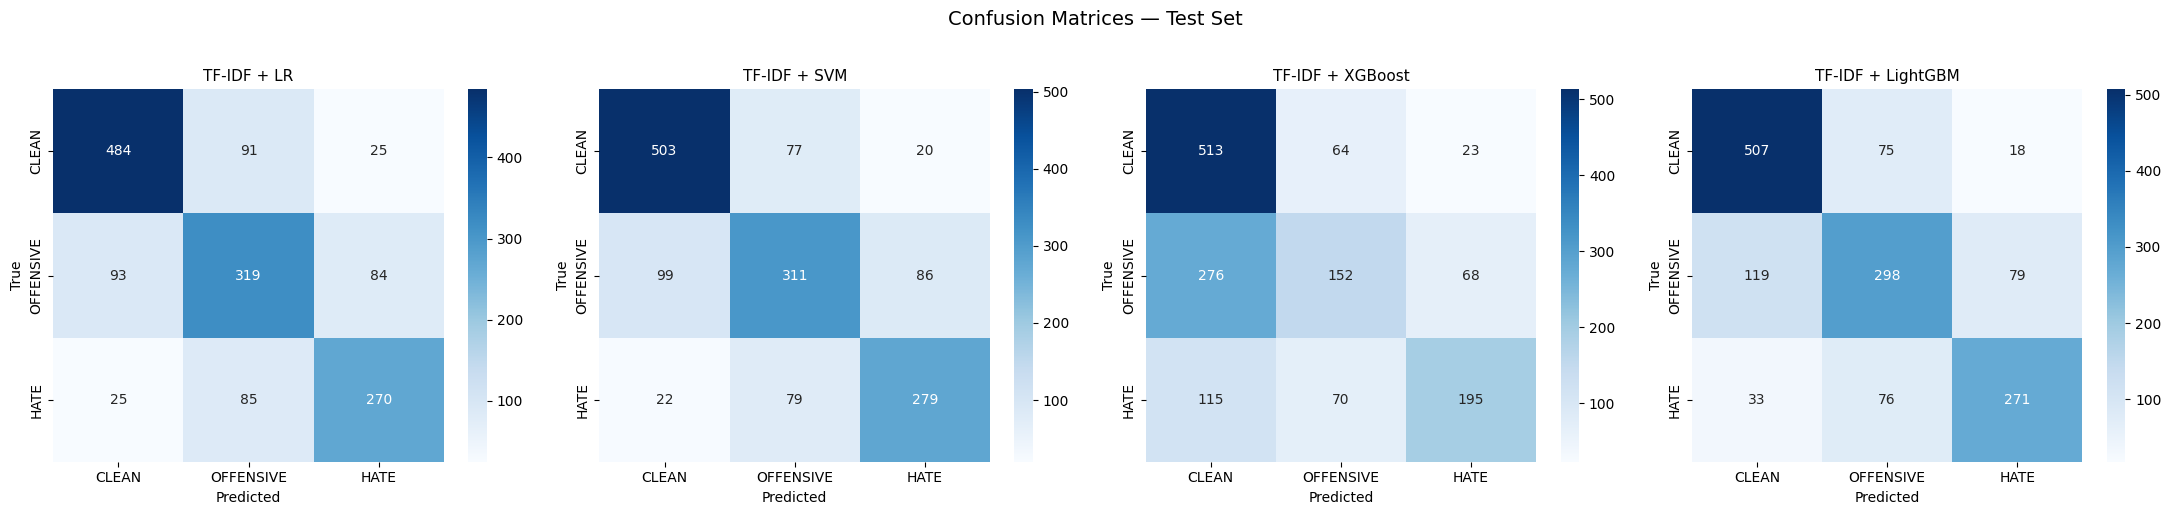

In [15]:
models_dict = {
    'TF-IDF + LR':       lr_model,
    'TF-IDF + SVM':      svm_model,
    'TF-IDF + XGBoost':  xgb_model,
    'TF-IDF + LightGBM': lgb_model,
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, model) in zip(axes, models_dict.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax,
    )
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Bảng kết quả tổng hợp

In [16]:
results_df = pd.DataFrame(results_table)

test_results = (
    results_df[results_df['Split'] == 'Test']
    .drop('Split', axis=1)
    .sort_values('F1 Macro', ascending=False)
    .reset_index(drop=True)
)

print('\n' + '=' * 75)
print('  KẾT QUẢ TRÊN TEST SET — ViHSD Baseline ML (Tuned)')
print('=' * 75)
print(test_results.to_string(index=False))
print('=' * 75)

best = test_results.iloc[0]
print(f'\n🏆 Best model: {best["Model"]}  (F1 Macro = {best["F1 Macro"]})')


  KẾT QUẢ TRÊN TEST SET — ViHSD Baseline ML (Tuned)
                    Model  Accuracy  F1 Macro  F1 Weighted  F1 CLEAN  F1 OFFENSIVE  F1 HATE
     TF-IDF + SVM (Tuned)    0.7405    0.7324       0.7389    0.8219        0.6459   0.7294
      TF-IDF + LR (Tuned)    0.7270    0.7202       0.7269    0.8053        0.6438   0.7115
TF-IDF + LightGBM (Tuned)    0.7290    0.7202       0.7259    0.8054        0.6307   0.7246
 TF-IDF + XGBoost (Tuned)    0.5827    0.5522       0.5587    0.6822        0.3887   0.5856

🏆 Best model: TF-IDF + SVM (Tuned)  (F1 Macro = 0.7324)


## 14. Visualization so sánh

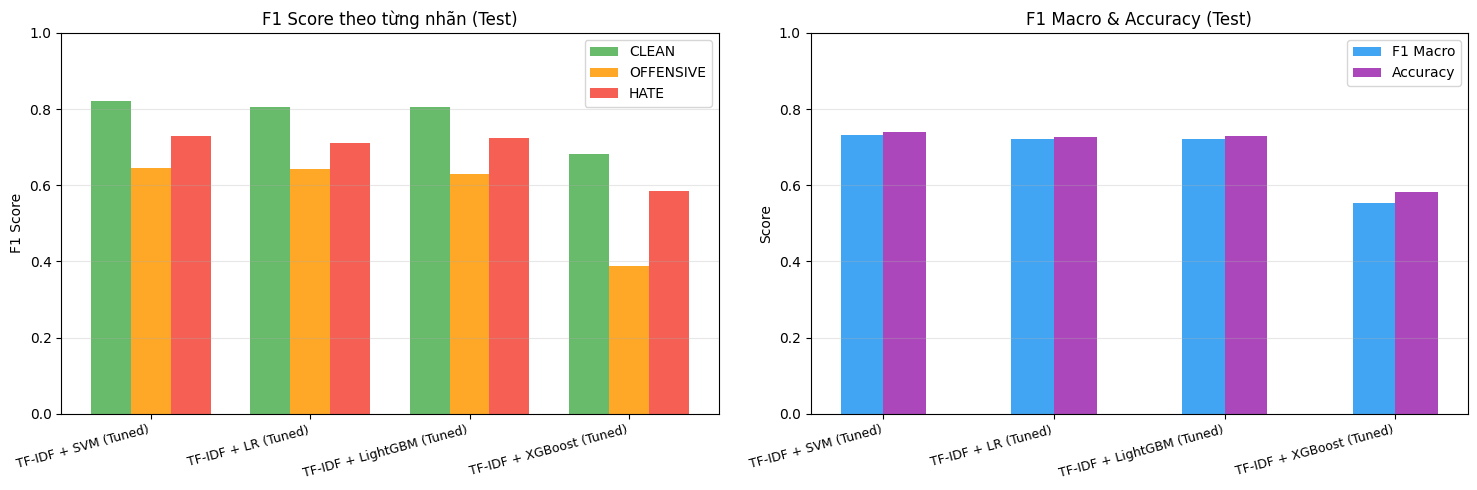

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
models_list = test_results['Model'].tolist()
x = np.arange(len(models_list))
w = 0.25

# F1 per class
ax = axes[0]
ax.bar(x - w, test_results['F1 CLEAN'],     w, label='CLEAN',     color='#4CAF50', alpha=0.85)
ax.bar(x,     test_results['F1 OFFENSIVE'],  w, label='OFFENSIVE', color='#FF9800', alpha=0.85)
ax.bar(x + w, test_results['F1 HATE'],       w, label='HATE',      color='#F44336', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score theo từng nhãn (Test)')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# F1 Macro + Accuracy
ax2 = axes[1]
ax2.bar(x - w/2, test_results['F1 Macro'], w, label='F1 Macro', color='#2196F3', alpha=0.85)
ax2.bar(x + w/2, test_results['Accuracy'], w, label='Accuracy', color='#9C27B0', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(models_list, rotation=15, ha='right', fontsize=9)
ax2.set_ylabel('Score')
ax2.set_title('F1 Macro & Accuracy (Test)')
ax2.legend()
ax2.set_ylim(0, 1.0)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Lưu models & kết quả

In [18]:
import joblib, os

os.makedirs('models', exist_ok=True)

joblib.dump(tfidf,     'models/tfidf_vectorizer.pkl')
joblib.dump(lr_model,  'models/lr_model.pkl')
joblib.dump(svm_model, 'models/svm_model.pkl')
xgb_model.save_model('models/xgb_model.json')
lgb_model.booster_.save_model('models/lgb_model.txt')

results_df.to_csv('baseline_ml_results.csv', index=False)

print('Saved:')
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f'  models/{f}  ({size:.0f} KB)')
print('  baseline_ml_results.csv')
print('  baseline_ml_results.png')
print('  confusion_matrices.png')

Saved:
  models/lgb_model.txt  (5410 KB)
  models/lr_model.pkl  (271 KB)
  models/svm_model.pkl  (812 KB)
  models/tfidf_vectorizer.pkl  (446 KB)
  models/xgb_model.json  (1091 KB)
  baseline_ml_results.csv
  baseline_ml_results.png
  confusion_matrices.png


## 16. Optuna Tuning Summary

In [19]:
print('=== Optuna Best Trials ===\n')
for name, study in [('LR', study_lr), ('SVM', study_svm),
                     ('XGBoost', study_xgb), ('LightGBM', study_lgb)]:
    print(f'{name}: F1 Macro = {study.best_value:.4f}')
    for k, v in study.best_params.items():
        print(f'  {k}: {v}')
    print()

# Dev vs Test comparison
print('\n=== Dev vs Test ===')
pivot = results_df.pivot_table(
    index='Model', columns='Split',
    values=['Accuracy', 'F1 Macro', 'F1 HATE'],
    aggfunc='first',
)
print(pivot.to_string())

=== Optuna Best Trials ===

LR: F1 Macro = 0.7346
  C: 90.31305460709692

SVM: F1 Macro = 0.7411
  C: 2.845394470672043

XGBoost: F1 Macro = 0.5436
  n_estimators: 700
  max_depth: 4
  learning_rate: 0.04558578355132234
  subsample: 0.6636890731460866
  colsample_bytree: 0.5791523748147592
  min_child_weight: 7
  reg_alpha: 0.00013742372908211674
  reg_lambda: 0.15207462111712533

LightGBM: F1 Macro = 0.7330
  n_estimators: 800
  max_depth: 8
  learning_rate: 0.03479792166728096
  num_leaves: 112
  subsample: 0.9981926492013293
  colsample_bytree: 0.9501945220447685
  min_child_samples: 5
  reg_alpha: 0.0070569457857090285
  reg_lambda: 0.01607993335992904


=== Dev vs Test ===
                          Accuracy         F1 HATE         F1 Macro        
Split                          Dev    Test     Dev    Test      Dev    Test
Model                                                                      
TF-IDF + LR (Tuned)         0.7398  0.7270  0.7413  0.7115   0.7346  0.7202
TF-IDF + 

## 17. Predict để kiểm chứng nhanh

Nhập một câu bất kỳ và chạy dự đoán với từng model để kiểm chứng đầu ra.

In [ ]:
def predict_text(text, model, tfidf_vectorizer, label_names):
    """Preprocess + vectorize + predict 1 câu văn bản."""
    cleaned = preprocess(text)
    X_one = tfidf_vectorizer.transform([cleaned])
    pred_idx = int(model.predict(X_one)[0])
    pred_label = label_names[pred_idx]
    score_info = None
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_one)[0]
        score_info = {label_names[i]: float(probs[i]) for i in range(len(label_names))}
    return {
        'raw_text': text,
        'processed_text': cleaned,
        'pred_idx': pred_idx,
        'pred_label': pred_label,
        'scores': score_info,
    }

# ── Test cases: (text, expected_label) ──────────────────────
TEST_CASES = [
    ("Hôm nay trời đẹp quá, đi chơi thôi!",                   "CLEAN"),
    ("Tụi nó toàn nói nhảm, đúng là quá toxic",                "OFFENSIVE"),
    ("Đồ ngu, câm miệng lại đi mày",                           "OFFENSIVE"),
    ("Tao ghét cái loại người như mày, xéo đi cho khuất mắt",  "HATE"),
    ("Cảm ơn bạn đã giúp đỡ mình nhé!",                        "CLEAN"),
    ('Tao cảm ơn mày nhiều lắm',                              "CLEAN")
]

if 'models_dict' not in globals():
    models_dict = {
        'TF-IDF + LR':       lr_model,
        'TF-IDF + SVM':      svm_model,
        'TF-IDF + XGBoost':  xgb_model,
        'TF-IDF + LightGBM': lgb_model,
    }

print('=' * 70)
print('  PREDICT VERIFICATION')
print('=' * 70)

correct_counts = {name: 0 for name in models_dict}

for text, expected in TEST_CASES:
    print(f'\nInput    : {text}')
    print(f'Expected : {expected}')
    print(f'Processed: {preprocess(text)}')
    print(f'{"─" * 70}')
    print(f'  {"Model":<25} {"Predicted":<12} {"Match":<8} {"Probabilities"}')
    print(f'  {"─"*25} {"─"*12} {"─"*8} {"─"*25}')

    for name, mdl in models_dict.items():
        out = predict_text(text, mdl, tfidf, LABEL_NAMES)
        match = "OK" if out['pred_label'] == expected else "WRONG"
        if out['pred_label'] == expected:
            correct_counts[name] += 1

        if out['scores']:
            proba_str = ' | '.join([f'{k}: {v:.2f}' for k, v in out['scores'].items()])
        else:
            proba_str = 'N/A'

        print(f'  {name:<25} {out["pred_label"]:<12} {match:<8} {proba_str}')

# ── Accuracy summary ─────────────────────────────────────────
print(f'\n{"=" * 70}')
print(f'  SUMMARY ({len(TEST_CASES)} test cases)')
print(f'{"=" * 70}')
print(f'  {"Model":<25} {"Correct":<10} {"Accuracy":<10} {"Bar"}')
print(f'  {"─"*25} {"─"*10} {"─"*10} {"─"*10}')
for name, correct in correct_counts.items():
    acc = correct / len(TEST_CASES) * 100
    bar = '#' * correct + '.' * (len(TEST_CASES) - correct)
    print(f'  {name:<25} {correct}/{len(TEST_CASES):<8}  {acc:5.1f}%    {bar}')